100.0%
100.0%
100.0%
100.0%


[LR=0.1] Epoch 1/5 | Loss=0.3207 | Test Acc=97.34%
[LR=0.1] Epoch 2/5 | Loss=0.0706 | Test Acc=98.56%
[LR=0.1] Epoch 3/5 | Loss=0.0484 | Test Acc=98.95%
[LR=0.1] Epoch 4/5 | Loss=0.0367 | Test Acc=97.07%
[LR=0.1] Epoch 5/5 | Loss=0.0305 | Test Acc=98.04%
[LR=0.01] Epoch 1/5 | Loss=1.2656 | Test Acc=90.01%
[LR=0.01] Epoch 2/5 | Loss=0.2856 | Test Acc=94.06%
[LR=0.01] Epoch 3/5 | Loss=0.1911 | Test Acc=95.78%
[LR=0.01] Epoch 4/5 | Loss=0.1381 | Test Acc=96.58%
[LR=0.01] Epoch 5/5 | Loss=0.1098 | Test Acc=97.15%
[LR=0.001] Epoch 1/5 | Loss=2.2815 | Test Acc=35.87%
[LR=0.001] Epoch 2/5 | Loss=2.1960 | Test Acc=64.43%
[LR=0.001] Epoch 3/5 | Loss=1.8474 | Test Acc=70.04%
[LR=0.001] Epoch 4/5 | Loss=1.0138 | Test Acc=82.36%
[LR=0.001] Epoch 5/5 | Loss=0.5985 | Test Acc=86.93%


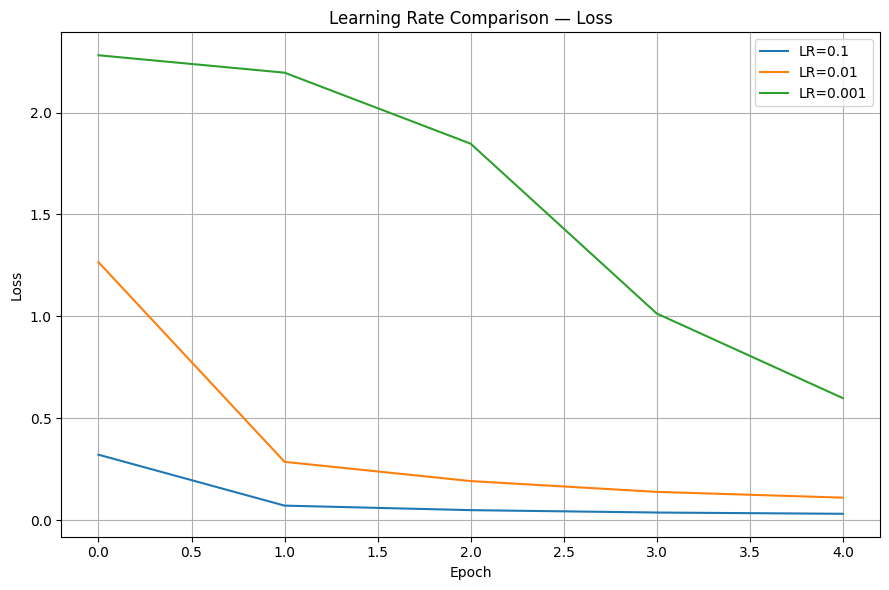

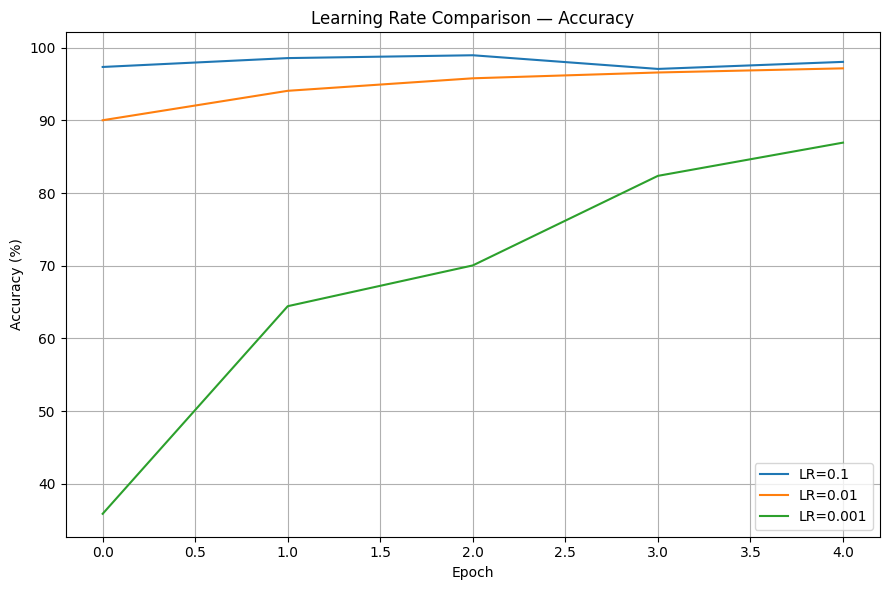

\nخلاصه‌ی دقت‌های نهایی:
  LR=0.1     → Test Acc = 98.04%
  LR=0.01    → Test Acc = 97.15%
  LR=0.001   → Test Acc = 86.93%


In [1]:
"""
آموزش گام‌به‌گام: از صفر تا اجرای یک CNN روی MNIST + آزمایش چند Learning Rate
=============================================================================

چرا این فایل؟
-------------
اگر از خودت می‌پرسی «از کجا شروع کنم؟ چرا class؟ چرا def؟ چرا for؟»،
این فایل دقیقاً برای توست: یک "الگوی ذهنی ۸ بخشی" می‌دهد که هر بار می‌توانی
از روی آن بسازی و تغییرش بدهی.

الگوی ذهنی ۸ بخشی (برای به خاطر سپردنِ ترتیب کار در PyTorch)
------------------------------------------------------------
1) وارد کردن کتابخانه‌ها + ثابت‌ها (seed/device/hparams)
2) آماده‌سازی داده‌ها: Dataset / Transform / DataLoader
3) تعریف مدل (class ... nn.Module) + forward
   - چرا class؟ تا پارامترها/لایه‌ها عضو شیء باشند و PyTorch آنها را ردیابی کند.
   - چرا forward؟ تا مسیر محاسبه‌ی پیشرو شفاف باشد و autograd بتواند گرادیان بگیرد.
4) تعریف تابع هزینه (loss) و بهینه‌ساز (optimizer)
5) نوشتن تابع train_one_epoch (def ...)
   - چرا def؟ خوانایی + قابلیت استفاده مجدد + تست آسان
6) نوشتن تابع evaluate (def ...)
7) نوشتن تابع run_experiment(lr=...) برای اجرای یک تجربه با LR مشخص
8) حلقه/منطق آزمایش‌ها (for هر LR) + رسم نمودارها + گزارش نتایج

چرا for؟
---------
- for epoch in range(E): برای تکرار دوره‌های آموزش
- for images, labels in loader: برای پیمایش مینی‌بچ‌ها (به‌صرفه و پایدار)

نکته‌ی نمایش فارسی در نمودارها
-------------------------------
- Matplotlib به‌صورت پیش‌فرض در نمایش فارسی مشکل bidi/شکل‌دهی دارد.
- اگر کتابخانه‌های `arabic_reshaper` و `python-bidi` و یک فونت فارسی نصب داری،
  متغیر ENABLE_PERSIAN_TITLES را True کن تا عنوان‌های فارسی درست نمایش داده شوند.
- در غیر این‌صورت، عنوان‌ها انگلیسی‌اند تا وارونه/به‌هم‌ریخته نشوند.

نکته‌ی اجرای فایل
-----------------
- نیازمندی‌ها: torch, torchvision, matplotlib
- اجرای نمونه:
    pip install torch torchvision matplotlib arabic-reshaper python-bidi
    python mnist_cnn_lr_experiment_fa.py
- بارِ اول دیتاست MNIST دانلود می‌شود (اتصال اینترنت لازم است).
"""

# ------------------------------------------------------------
# (1) وارد کردن کتابخانه‌ها + ثابت‌ها (seed/device/hparams)
# ------------------------------------------------------------
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms

# 🔸 سوئیچ نمایش فارسی در نمودارها (در صورت داشتن پیش‌نیازها)
ENABLE_PERSIAN_TITLES = False

# تلاش برای راه‌اندازی reshape/bidi اگر کاربر خواسته باشد
if ENABLE_PERSIAN_TITLES:
    try:
        import arabic_reshaper
        from bidi.algorithm import get_display
        HAS_RTL = True
    except Exception:
        HAS_RTL = False
else:
    HAS_RTL = False

def fa(text: str) -> str:
    """اگر نمایش RTL فعال باشد، متن فارسی را reshape + bidi می‌کنیم، وگرنه همان متن برگردانده می‌شود."""
    if HAS_RTL:
        return get_display(arabic_reshaper.reshape(text))
    return text

# ✅ بذر تصادفی برای تکرارپذیری نتایج
def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

# ✅ انتخاب دستگاه اجرا (GPU اگر موجود باشد)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ✅ ابرپارامترهای پایه
batch_size   = 64     # اندازه‌ی مینی‌بچ
num_epochs   = 5      # تعداد دوره‌های آموزش (برای MNIST همین مقدار هم تفاوت LR را نشان می‌دهد)
learning_rates = [0.1, 0.01, 0.001]  # سه LR: بزرگ/متوسط/کوچک


# ------------------------------------------------------------
# (2) آماده‌سازی داده‌ها: Dataset / Transform / DataLoader
# ------------------------------------------------------------
"""
چرا Transform؟
- ToTensor: تصویر [0..255] را به [0..1] تبدیل می‌کند و به Tensor با شکل (C,H,W) درمی‌آورد.
- Normalize: میانگین/انحراف معیار را ثابت می‌کند تا آموزش پایدارتر شود.
  (برای MNIST اغلب کافی است فقط ToTensor استفاده کنیم؛ اینجا normalize را هم نشان می‌دهیم.)

چرا DataLoader؟
- مینی‌بچ ساختن، شافل کردن، و بهره‌برداری از پردازش موازی (num_workers).
"""
transform = transforms.Compose([
    transforms.ToTensor(),
    # اگر خواستی می‌توانی نرمال‌سازی را فعال کنی؛ MNIST سیاه‌وسفید است.
    # transforms.Normalize((0.1307,), (0.3081,))
])

train_dataset = torchvision.datasets.MNIST(
    root="./data", train=True, download=True, transform=transform
)
test_dataset = torchvision.datasets.MNIST(
    root="./data", train=False, download=True, transform=transform
)

train_loader = torch.utils.data.DataLoader(
    train_dataset, batch_size=batch_size, shuffle=True, num_workers=0
)
test_loader = torch.utils.data.DataLoader(
    test_dataset, batch_size=1000, shuffle=False, num_workers=0
)


# ------------------------------------------------------------
# (3) تعریف مدل CNN به‌صورت کلاس (nn.Module) + forward
# ------------------------------------------------------------
"""
چرا class و nn.Module؟
- هر لایه (Conv/Linear/...) خودش پارامتر دارد؛ وقتی آنها را درون کلاسِ فرزندِ nn.Module تعریف می‌کنی،
  PyTorch به صورت خودکار آنها را به‌عنوان "پارامتر قابل آموزش" ثبت می‌کند (model.parameters()).
- forward مسیر محاسبات پیشرو را تعریف می‌کند؛ autograd با رهگیری این مسیر، گرادیان‌ها را حساب می‌کند.

معماری ساده‌ی ما برای MNIST (1×28×28):
- Conv2d(1 → 32, kernel=3, padding=1) + ReLU + MaxPool(2)
- Conv2d(32 → 64, kernel=3, padding=1) + ReLU + MaxPool(2)
- خروجی بعد از دو بار pooling از 28→14→7 می‌رسد؛ تعداد نقشه‌ها 64 است → شکل نهایی: (64, 7, 7)
- سپس flatten → Linear(64*7*7 → 128) + ReLU → Linear(128 → 10)
"""
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        # 🔹 بلوک کانولوشن اول
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, padding=1)
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool2d(kernel_size=2)  # 28→14

        # 🔹 بلوک کانولوشن دوم
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d(kernel_size=2)  # 14→7

        # 🔹 لایه‌های کاملاً متصل
        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.relu3 = nn.ReLU()
        self.fc2 = nn.Linear(128, 10)  # 10 کلاس MNIST

    def forward(self, x):
        """
        🔵 forward: مسیر محاسبه از ورودی تا خروجی (logits).
        - چرا logits و نه softmax؟ چون CrossEntropyLoss خودش softmax را درونی اعمال می‌کند.
        """
        # x: شکل (batch_size, 1, 28, 28)
        x = self.conv1(x)   # → (batch, 32, 28, 28)
        x = self.relu1(x)
        x = self.pool1(x)   # → (batch, 32, 14, 14)

        x = self.conv2(x)   # → (batch, 64, 14, 14)
        x = self.relu2(x)
        x = self.pool2(x)   # → (batch, 64, 7, 7)

        # 🔸 تخت کردن برای ورود به لایه‌ی خطی
        x = x.view(x.size(0), -1)  # → (batch, 64*7*7)

        x = self.fc1(x)     # → (batch, 128)
        x = self.relu3(x)
        x = self.fc2(x)     # → (batch, 10) = logits
        return x


# ------------------------------------------------------------
# (4) تعریف تابع هزینه و بهینه‌ساز
# ------------------------------------------------------------
"""
- criterion = CrossEntropyLoss: مناسب برای طبقه‌بندی چندکلاسه؛ خودش softmax داخلی دارد.
- optimizer = SGD: برای آزمایش اثر Learning Rate ساده‌ترین انتخاب است.
  (در گام بعدی می‌توانیم Momentum/RMSProp/Adam را اضافه کنیم.)
"""
criterion = nn.CrossEntropyLoss()


# ------------------------------------------------------------
# (5) نوشتن train_one_epoch: یک دور کامل آموزش
# ------------------------------------------------------------
def train_one_epoch(model, loader, optimizer):
    """
    چرا train_one_epoch؟
    - جداسازی منطق آموزش از بقیه‌ی کد → خواناتر/قابل‌تست‌تر
    - داخل این تابع، مراحل استاندارد آموزش را انجام می‌دهیم:
      1) model.train(): فعال‌سازی حالت آموزش (بخصوص برای لایه‌هایی مثل Dropout/BatchNorm)
      2) پیمایش مینی‌بچ‌ها با for
      3) optimizer.zero_grad(): پاک‌کردن گرادیان‌های قبلی
      4) forward: پیش‌بینی مدل روی batch
      5) loss = criterion(outputs, labels): محاسبه‌ی خطا
      6) loss.backward(): بک‌پراپ خودکار (autograd)
      7) optimizer.step(): به‌روزرسانی وزن‌ها با توجه به LR و گرادیان‌ها
    خروجی: میانگین loss این epoch
    """
    model.train()
    running_loss = 0.0
    for images, labels in loader:                     # ← for: پیمایش batchها
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()                         # 3) پاک‌کردن گرادیان‌های قبلی
        outputs = model(images)                       # 4) 🔵 forward
        loss = criterion(outputs, labels)             # 5) محاسبه‌ی loss
        loss.backward()                               # 6) 🔴 backward (گرادیان‌ها)
        optimizer.step()                              # 7) ✳️ به‌روزرسانی وزن‌ها

        running_loss += loss.item()

    avg_loss = running_loss / len(loader)
    return avg_loss


# ------------------------------------------------------------
# (6) نوشتن evaluate: ارزیابی دقت روی داده‌ی تست
# ------------------------------------------------------------
@torch.no_grad()
def evaluate(model, loader):
    """
    چرا torch.no_grad؟
    - در ارزیابی نیازی به گرادیان نداریم → حافظه و سرعت بهتر.
    منطق:
    - model.eval(): حالت ارزیابی
    - پیمایش تست، گرفتن logits، انتخاب کلاس با argmax، شمارش درست‌ها
    خروجی: دقت (Accuracy) درصدی
    """
    model.eval()
    correct, total = 0, 0
    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)
        logits = model(images)                        # 🔵 forward فقط برای پیش‌بینی
        preds = logits.argmax(dim=1)                  # کلاس با بیشترین لاجیت
        total += labels.size(0)
        correct += (preds == labels).sum().item()
    return 100.0 * correct / total


# ------------------------------------------------------------
# (7) run_experiment: اجرای یک آزمایش با LR مشخص
# ------------------------------------------------------------
def run_experiment(lr: float, epochs: int = 5):
    """
    چرا تابع جداگانه؟
    - هر بار یک مدل تازه با LR دلخواه می‌سازیم تا اثر تجربه‌های قبلی باقی نماند.
    - تاریخچه‌ی loss/accuracy را جمع می‌کنیم تا بعداً مقایسه کنیم.
    """
    model = SimpleCNN().to(device)
    optimizer = optim.SGD(model.parameters(), lr=lr)

    loss_hist = []
    acc_hist  = []

    for epoch in range(epochs):
        avg_loss = train_one_epoch(model, train_loader, optimizer)
        acc = evaluate(model, test_loader)

        loss_hist.append(avg_loss)
        acc_hist.append(acc)

        print(f"[LR={lr}] Epoch {epoch+1}/{epochs} | Loss={avg_loss:.4f} | Test Acc={acc:.2f}%")

    return {"loss": loss_hist, "acc": acc_hist}


# ------------------------------------------------------------
# (8) حلقه‌ی آزمایش‌ها: اجرای چند LR و ترسیم نمودارها
# ------------------------------------------------------------
def main():
    results = {}
    for lr in learning_rates:                 # ← for: اجرای تجربه برای هر LR
        results[lr] = run_experiment(lr, epochs=num_epochs)

    # 🔻 نمودار 1: روند Loss (همه‌ی LRها روی یک نمودار)
    plt.figure(figsize=(9,6))
    for lr in learning_rates:
        plt.plot(results[lr]["loss"], label=f"LR={lr}")
    title_loss = "Learning Rate Comparison — Loss" if not HAS_RTL else fa("مقایسه‌ی نرخ یادگیری — روند Loss")
    plt.title(title_loss)
    plt.xlabel("Epoch" if not HAS_RTL else fa("دوره‌ی آموزش (Epoch)"))
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig("mnist_cnn_loss.png", dpi=150)
    plt.show()

    # 🔻 نمودار 2: روند Accuracy (همه‌ی LRها روی یک نمودار)
    plt.figure(figsize=(9,6))
    for lr in learning_rates:
        plt.plot(results[lr]["acc"], label=f"LR={lr}")
    title_acc = "Learning Rate Comparison — Accuracy" if not HAS_RTL else fa("مقایسه‌ی نرخ یادگیری — روند دقت (Accuracy)")
    plt.title(title_acc)
    plt.xlabel("Epoch" if not HAS_RTL else fa("دوره‌ی آموزش (Epoch)"))
    plt.ylabel("Accuracy (%)")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig("mnist_cnn_acc.png", dpi=150)
    plt.show()

    # 🔻 چاپ خلاصه‌ی نتایج نهایی (آخرین دقت هر LR)
    print("\\nخلاصه‌ی دقت‌های نهایی:")
    for lr in learning_rates:
        final_acc = results[lr]["acc"][-1]
        print(f"  LR={lr:<7} → Test Acc = {final_acc:.2f}%")

if __name__ == "__main__":
    main()
